In [2]:
from keras.layers import *
from keras.models import Model, load_model
from keras.datasets import mnist
from keras.datasets import fashion_mnist
from keras.callbacks import ReduceLROnPlateau
from keras import regularizers
from keras import optimizers
from keras import backend as K
import scipy
import matplotlib.pyplot as plt
from matplotlib.offsetbox import OffsetImage, AnnotationBbox, TextArea
import pandas as pd
import numpy as np

In [3]:
(x_train, _), (x_test, _) = fashion_mnist.load_data()

x_train = x_train.astype("float32") / 255
x_test = x_test.astype("float32") / 255

In [7]:
# полносвязная автоэнкодер
x_train_fc = x_train.reshape(-1, 784)
x_test_fc = x_test.reshape(-1, 784)

In [ ]:
input_img = Input(shape=(784,))

# encoder
encoded = Dense(784, activation='relu')(input_img)
encoded = Dense(256, activation='relu')(encoded)
encoded = Dense(128, activation='relu')(encoded) 
encoded = Dense(64, activation='relu')(encoded)
encoded = Dense(2, activation='relu')(encoded)


In [9]:
# decoder
decoded = Dense(64, activation='relu')(encoded)
decoded = Dense(128, activation='relu')(decoded)
decoded = Dense(256, activation='relu')(decoded)
decoded = Dense(784, activation='sigmoid')(decoded)

In [10]:
autoencoder_fc = Model(input_img, decoded)
autoencoder_fc.compile(optimizer='adam', loss='binary_crossentropy')

print(autoencoder_fc.summary())

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 784)            │       615,440 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 256)            │       200,960 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 8)              │           136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 2)              │            18 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 64)             │           192 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 128)            │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 256)            │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 784)            │       201,488 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,103,338 (4.21 MB)

 Trainable params: 1,103,338 (4.21 MB)

 Non-trainable params: 0 (0.00 B)

None


In [11]:
history_fc = autoencoder_fc.fit(x_train_fc, x_train_fc,
                epochs=20, 
                batch_size=256, 
                shuffle=True,
                validation_data=(x_test_fc, x_test_fc))

Epoch 1/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 6s 14ms/step - loss: 0.4144 - val_loss: 0.3566
Epoch 2/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 4s 15ms/step - loss: 0.3463 - val_loss: 0.3403
Epoch 3/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 3s 15ms/step - loss: 0.3345 - val_loss: 0.3334
Epoch 4/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 3s 14ms/step - loss: 0.3298 - val_loss: 0.3305
Epoch 5/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 3s 13ms/step - loss: 0.3275 - val_loss: 0.3287
Epoch 6/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 3s 14ms/step - loss: 0.3261 - val_loss: 0.3272
Epoch 7/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 3s 13ms/step - loss: 0.3250 - val_loss: 0.3273
Epoch 8/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 3s 12ms/step - loss: 0.3242 - val_loss: 0.3259
Epoch 9/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 3s 12ms/step - loss: 0.3236 - val_loss: 0.3268
Epoch 10/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 3s 13ms/step - loss: 0.3233 - val_loss: 0.3247
Epoch 11/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 3s 13ms/step - loss: 0.3225 - val_loss: 0.3240
Epoch 12/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 

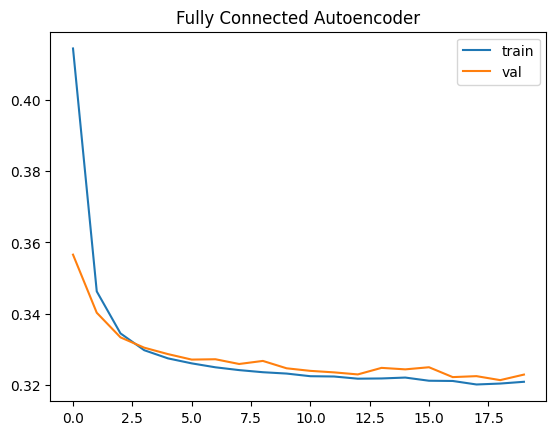

In [12]:
plt.plot(history_fc.history['loss'])
plt.plot(history_fc.history['val_loss'])
plt.title("Fully Connected Autoencoder")
plt.legend(["train","val"])
plt.show()

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


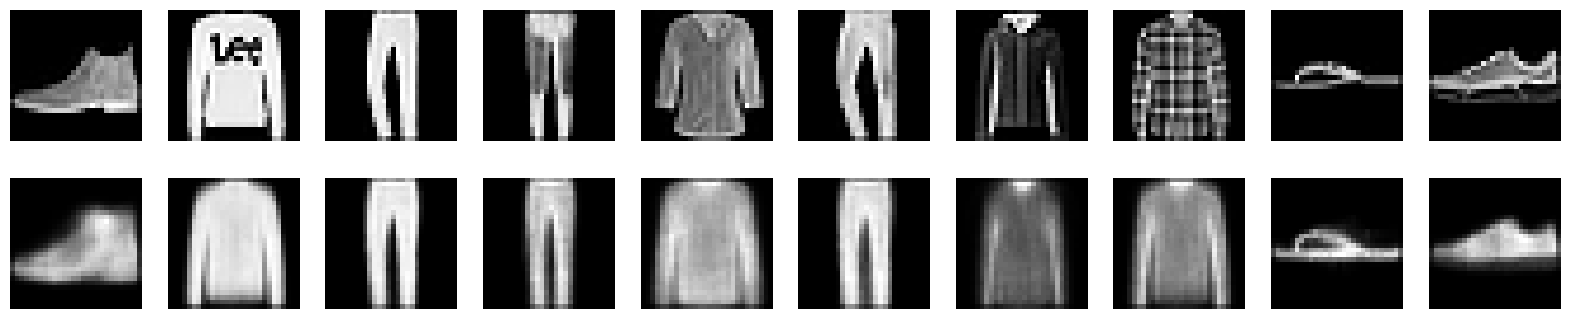

In [13]:
decoded_imgs = autoencoder_fc.predict(x_test_fc)

plt.figure(figsize=(20,4))

for i in range(10):

    ax = plt.subplot(2,10,i+1)
    plt.imshow(x_test[i], cmap='gray')
    plt.axis("off")

    ax = plt.subplot(2,10,i+11)
    plt.imshow(decoded_imgs[i].reshape(28,28), cmap='gray')
    plt.axis("off")

plt.show()

In [4]:
# CNN автоэнкодер
x_train_cnn = x_train.reshape(-1, 28, 28, 1)
x_test_cnn = x_test.reshape(-1, 28, 28, 1)

In [5]:
input_img = Input(shape=(28, 28, 1)) 

# encoder
x = Conv2D(32, (3, 3), activation='relu', padding='same')(input_img)
x = Conv2D(32, (3, 3), activation='relu', padding='same')(x)
x = MaxPooling2D((2, 2))(x)
x = BatchNormalization()(x)
x = Conv2D(32, (3, 3), activation='relu', padding='same')(x)
x = Conv2D(32, (3, 3), activation='relu', padding='same')(x)
x = Conv2D(32, (2, 2), activation='relu', padding='same')(x)
x = MaxPooling2D((2, 2))(x)
x = BatchNormalization()(x)
x = Conv2D(16, (2, 2), activation='relu', padding='same')(x)
x = Conv2D(4, (2, 2), activation='relu', padding='same')(x)
x = Conv2D(1, (2, 2), activation='relu', padding='same')(x)
x = Flatten()(x)
encoded = Dense(2, activation='relu')(x)

encoder = Model(inputs=input_img, outputs=encoded)
    
encoded_inputs = Input(shape=(2,))

    

In [6]:
# decoder
x = Dense(4, activation='relu')(encoded_inputs)
x = Reshape((2, 2, 1))(x)
x = Conv2D(4, (2, 2), activation='relu', padding='same')(x)
x = Conv2D(16, (2, 2), activation='relu', padding='same')(x)
x = BatchNormalization()(x)
x = UpSampling2D((7, 7))(x)
x = Conv2D(32, (3, 3), activation='relu', padding='same')(x)
x = Conv2D(32, (3, 3), activation='relu', padding='same')(x)
x = Conv2D(32, (3, 3), activation='relu', padding='same')(x)
x = BatchNormalization()(x)
x = UpSampling2D((2, 2))(x)
x = Conv2D(32, (3, 3), activation='relu', padding='same')(x)
x = Conv2D(32, (3, 3), activation='relu', padding='same')(x)
decoded = Conv2D(1, (3, 3), activation='sigmoid', padding='same')(x)

decoder = Model(inputs=encoded_inputs, outputs=decoded)


In [7]:
x = encoder(input_img)
x = decoder(x)
model = Model(inputs=input_img, outputs=x)
model.compile(optimizer=optimizers.Adam(1e-3), loss='binary_crossentropy', metrics=['accuracy', 'mse'])

print(model.summary())

Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 28, 28, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ functional (Functional)         │ (None, 2)              │        34,889 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ functional_1 (Functional)       │ (None, 28, 28, 1)      │        42,417 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 77,306 (301.98 KB)

 Trainable params: 77,082 (301.10 KB)

 Non-trainable params: 224 (896.00 B)

None


In [8]:
clr = ReduceLROnPlateau(
        monitor='loss',
        factor=0.5,
        patience=3,
        min_delta=0.01,
        cooldown=0,
        min_lr=1e-7,
        verbose=1)

model.fit(
        x_train,
        x_train,
        batch_size=256,
        epochs=50,
        shuffle=True,
        validation_data=(x_test, x_test),
        callbacks=[clr])

Epoch 1/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 75s 278ms/step - accuracy: 0.4926 - loss: 0.4322 - mse: 0.0646 - val_accuracy: 0.4999 - val_loss: 0.9048 - val_mse: 0.1787 - learning_rate: 0.0010
Epoch 2/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 47s 198ms/step - accuracy: 0.4937 - loss: 0.4038 - mse: 0.0547 - val_accuracy: 0.5002 - val_loss: 0.4680 - val_mse: 0.0778 - learning_rate: 0.0010
Epoch 3/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 47s 201ms/step - accuracy: 0.4945 - loss: 0.3981 - mse: 0.0527 - val_accuracy: 0.4954 - val_loss: 0.3961 - val_mse: 0.0512 - learning_rate: 0.0010
Epoch 4/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 47s 200ms/step - accuracy: 0.4952 - loss: 0.3940 - mse: 0.0513 - val_accuracy: 0.4822 - val_loss: 0.4114 - val_mse: 0.0575 - learning_rate: 0.0010
Epoch 5/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 47s 198ms/step - accuracy: 0.4958 - loss: 0.3909 - mse: 0.0502 - val_accuracy: 0.4900 - val_loss: 0.3951 - val_mse: 0.0512 - learning_rate: 0.0010
Epoch 6/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 47s 198ms/step - accuracy

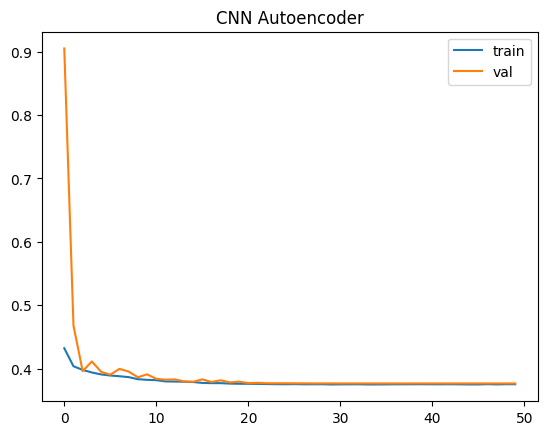

In [11]:
plt.plot(history_cnn.history['loss'])
plt.plot(history_cnn.history['val_loss'])
plt.title("CNN Autoencoder")
plt.legend(["train","val"])
plt.show()

313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 11ms/step


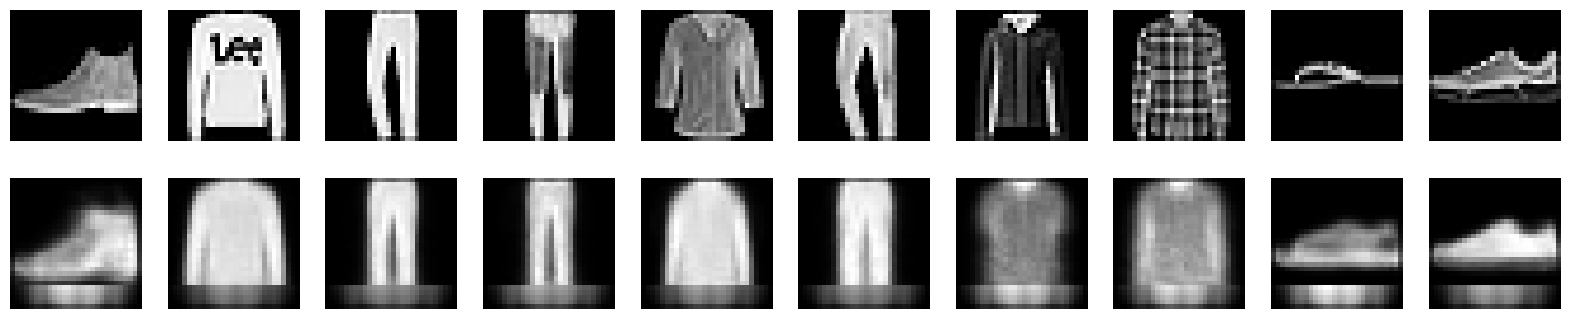

In [12]:
decoded_imgs = model.predict(x_test_cnn)

plt.figure(figsize=(20,4))

for i in range(10):

    ax = plt.subplot(2,10,i+1)
    plt.imshow(x_test[i], cmap='gray')
    plt.axis("off")

    ax = plt.subplot(2,10,i+11)
    plt.imshow(decoded_imgs[i].reshape(28,28), cmap='gray')
    plt.axis("off")

plt.show()